C:\Users\user\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (





Training Denoising AE...

Training VAE...
1/1 [==============================] - 0s 109ms/step


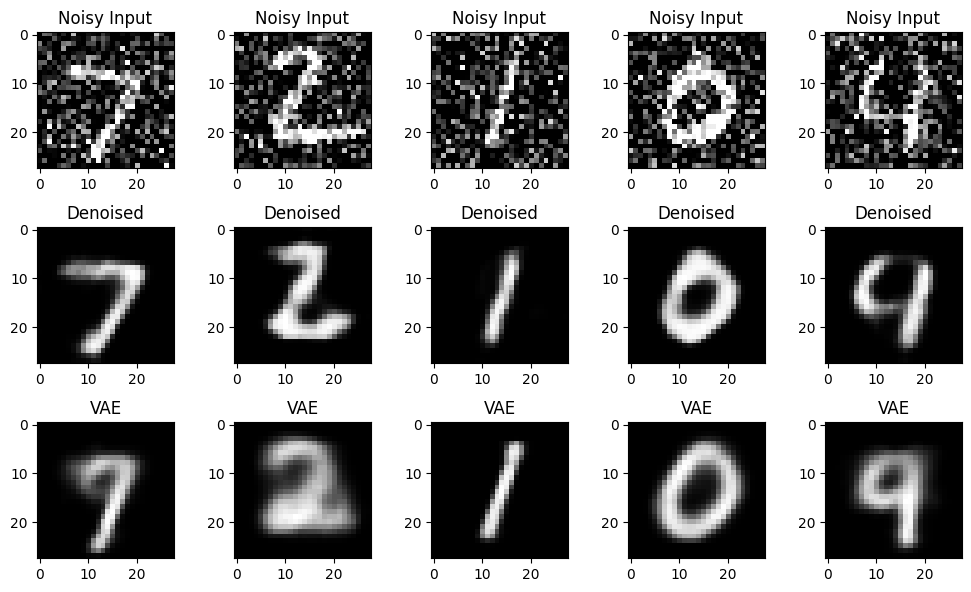

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, Model, losses, backend as K

# --- 1. DATA PREPARATION ---
(x_train, _), (x_test, _) = tf.keras.datasets.mnist.load_data()
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.
x_train = x_train[..., tf.newaxis]
x_test = x_test[..., tf.newaxis]

# Create noisy version for the Denoising Autoencoder
noise_factor = 0.4
x_train_noisy = x_train + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_train.shape)
x_test_noisy = x_test + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_test.shape)
x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

# --- 2. UNDERCOMPLETE AUTOENCODER (UAE) ---
# Forced dimensionality reduction via a small bottleneck
class UndercompleteAE(Model):
    def __init__(self, latent_dim=16):
        super().__init__()
        self.encoder = tf.keras.Sequential([
            layers.Input(shape=(28, 28, 1)),
            layers.Conv2D(16, 3, activation='relu', strides=2, padding='same'),
            layers.Conv2D(8, 3, activation='relu', strides=2, padding='same'),
            layers.Flatten(),
            layers.Dense(latent_dim, activation='relu', activity_regularizer=tf.keras.regularizers.l1(1e-5))
        ])
        self.decoder = tf.keras.Sequential([
            layers.Dense(7 * 7 * 8, activation='relu'),
            layers.Reshape((7, 7, 8)),
            layers.Conv2DTranspose(8, 3, strides=2, activation='relu', padding='same'),
            layers.Conv2DTranspose(16, 3, strides=2, activation='relu', padding='same'),
            layers.Conv2D(1, 3, activation='sigmoid', padding='same')
        ])

    def call(self, x):
        encoded = self.encoder(x)
        return self.decoder(encoded)

# --- 3. VARIATIONAL AUTOENCODER (VAE) ---
# Maps input to a distribution (mean and variance) for generative power
class VAE(Model):
    def __init__(self, latent_dim=2):
        super().__init__()
        self.latent_dim = latent_dim
        # Encoder
        encoder_inputs = layers.Input(shape=(28, 28, 1))
        x = layers.Conv2D(32, 3, activation="relu", strides=2, padding="same")(encoder_inputs)
        x = layers.Conv2D(64, 3, activation="relu", strides=2, padding="same")(x)
        x = layers.Flatten()(x)
        z_mean = layers.Dense(latent_dim, name="z_mean")(x)
        z_log_var = layers.Dense(latent_dim, name="z_log_var")(x)
        
        # Sampling layer
        def sampling(args):
            z_mean, z_log_var = args
            epsilon = K.random_normal(shape=(K.shape(z_mean)[0], latent_dim))
            return z_mean + K.exp(0.5 * z_log_var) * epsilon
        
        z = layers.Lambda(sampling)([z_mean, z_log_var])
        self.encoder = Model(encoder_inputs, [z_mean, z_log_var, z], name="encoder")
        
        # Decoder
        latent_inputs = layers.Input(shape=(latent_dim,))
        x = layers.Dense(7 * 7 * 64, activation="relu")(latent_inputs)
        x = layers.Reshape((7, 7, 64))(x)
        x = layers.Conv2DTranspose(64, 3, strides=2, activation="relu", padding="same")(x)
        x = layers.Conv2DTranspose(32, 3, strides=2, activation="relu", padding="same")(x)
        decoder_outputs = layers.Conv2D(1, 3, activation="sigmoid", padding="same")(x)
        self.decoder = Model(latent_inputs, decoder_outputs, name="decoder")

    def train_step(self, data):
        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(data)
            reconstruction = self.decoder(z)
            reconstruction_loss = tf.reduce_mean(tf.reduce_sum(losses.binary_crossentropy(data, reconstruction), axis=(1, 2)))
            kl_loss = -0.5 * (1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var))
            kl_loss = tf.reduce_mean(tf.reduce_sum(kl_loss, axis=1))
            total_loss = reconstruction_loss + kl_loss
        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        return {"loss": total_loss, "reconstruction_loss": reconstruction_loss, "kl_loss": kl_loss}

# --- 4. EXECUTION & COMPARISON ---

# Train Undercomplete/Denoising AE
uae = UndercompleteAE()
uae.compile(optimizer='adam', loss=losses.MeanSquaredError())
print("Training Denoising AE...")
uae.fit(x_train_noisy, x_train, epochs=5, batch_size=128, validation_data=(x_test_noisy, x_test), verbose=0)

# Train VAE
vae = VAE()
vae.compile(optimizer=tf.keras.optimizers.Adam())
print("Training VAE...")
vae.fit(x_train, epochs=5, batch_size=128, verbose=0)

# --- 5. VISUALIZATION ---
n = 5
decoded_imgs = uae.predict(x_test_noisy[:n])
_, _, z_samples = vae.encoder.predict(x_test[:n])
vae_imgs = vae.decoder.predict(z_samples)

plt.figure(figsize=(10, 6))
for i in range(n):
    # Original Noisy
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(x_test_noisy[i].reshape(28, 28), cmap='gray')
    plt.title("Noisy Input")
    # Denoised (UAE)
    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28), cmap='gray')
    plt.title("Denoised")
    # VAE Reconstruction
    ax = plt.subplot(3, n, i + 1 + 2*n)
    plt.imshow(vae_imgs[i].reshape(28, 28), cmap='gray')
    plt.title("VAE")
plt.tight_layout()
plt.show()
